# **Overview: Sales Forecasting Using Machine Learning**

This notebook focuses on predicting future sales using **machine learning models** trained on historical data. The workflow includes:

- **Problem Statement:** Predict sales based on past transaction trends.
- **Data Preprocessing:** Handling missing values, encoding categorical features, and applying log transformation to stabilize variance.
- **Feature Engineering:** Creating time-based features (hour, day, month, year) and encoding categorical variables.
- **Model Training:** Using **XGBoost Regressor** with hyperparameter tuning for optimal performance.
- **Evaluation:** Assessing model accuracy using **MAE, RMSE, and R² Score** on unseen data.
- **Predictions:** Transforming results back to original scale for meaningful interpretation.

The objective is to **build an accurate and generalizable model** that helps in better sales forecasting and business planning.


# 1. Importing Required Libraries  
   - Loads essential Python libraries for data manipulation, visualization, machine learning, and preprocessing.  
   - Includes `pandas`, `numpy`, `seaborn`, `matplotlib`, `sklearn`, `xgboost`, and `scipy`.



In [808]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import skew
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 2. Loading Dataset  
   - Reads the `supermarket_sales.csv` dataset into a Pandas DataFrame.  
   - Displays the first few rows to understand the structure.

In [809]:
# Loading dataset
df = pd.read_csv("/kaggle/input/supermarket-sales/supermarket_sales - Sheet1.csv")

In [810]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


# 3. Exploratory Data Analysis (EDA)  
   - Analyzes the dataset to uncover patterns, missing values, and data distributions.  
   - Includes summary statistics, visualizations (histograms, box plots), and correlation matrices.

In [811]:
# Checking for missing values
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [813]:
# Checking for Types of data in each column
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [497]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [814]:
# Aggregate total sales by Product line
product_sales = df.groupby("Product line")["Total"].sum()
product_sales

Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Total, dtype: float64

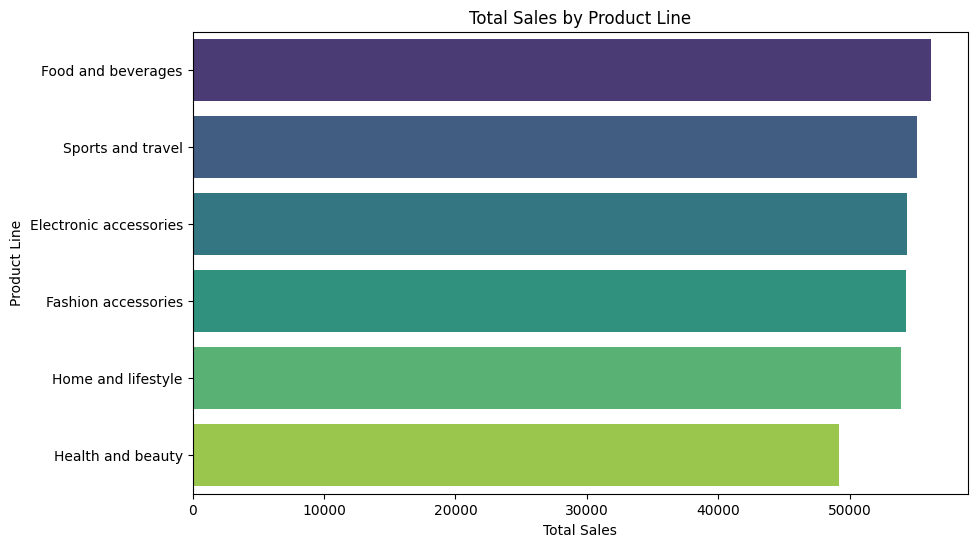

In [819]:
# Grouping sales by product line
sales_by_product = df.groupby('Product line')['Total'].sum().reset_index()

# Sorting for better visualization
sales_by_product = sales_by_product.sort_values(by='Total', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Total', y='Product line', data=sales_by_product, palette='viridis')

# Labels and Title
plt.xlabel("Total Sales")
plt.ylabel("Product Line")
plt.title("Total Sales by Product Line")
plt.show()

In [820]:
# Aggregate total sales by branch
branch_sales = df.groupby("Branch")["Total"].sum()
branch_sales

Branch
A    106200.3705
B    106197.6720
C    110568.7065
Name: Total, dtype: float64

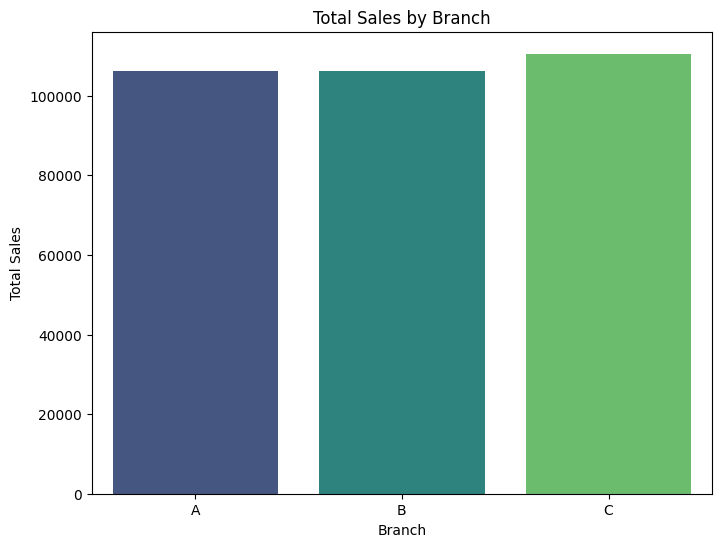

In [821]:
# Aggregate total sales by branch
branch_sales = df.groupby("Branch")["Total"].sum().reset_index()

# Plot sales per branch
plt.figure(figsize=(8,6))
sns.barplot(x="Branch", y="Total", data=branch_sales, palette="viridis")

# Labels and title
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.title("Total Sales by Branch")
plt.show()

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


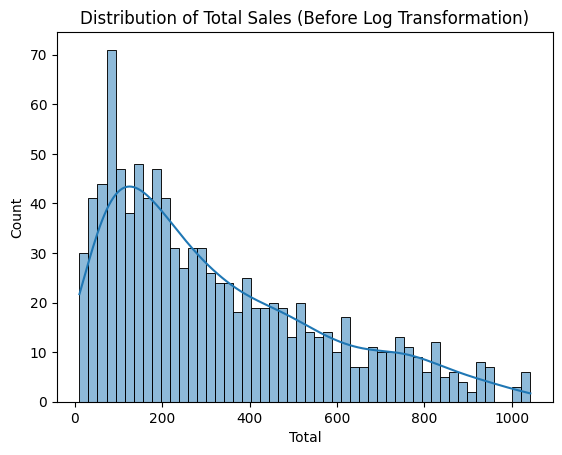

In [822]:
sns.histplot(df['Total'], bins=50, kde=True)
plt.title("Distribution of Total Sales (Before Log Transformation)")
plt.show()

# 4. Feature Engineering  
   - Creates new features to improve model performance.  
   - Includes transformations like **log scaling**, handling categorical variables, and extracting time-based features.

In [498]:
# Converting date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')  

In [499]:
# Extracting features from date & time
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

In [501]:
df['Total'] = np.log1p(df['Total'])  # Log(1 + Total) to reduce skewness

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


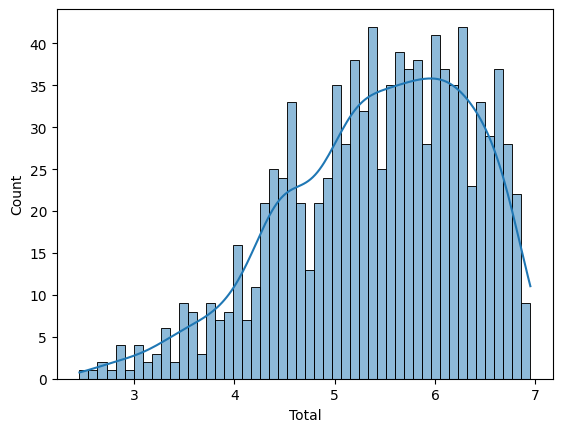

In [502]:

sns.histplot(df['Total'], bins=50, kde=True)
plt.show()

In [503]:
numerical_features = ['Unit price', 'Quantity', 'Branch_encoded', 'hour', 'day', 'month', 'year']
X = df[numerical_features]  # Define X (features)
y = df['Total']  # Define target variable

## 5. One-Hot Encoding  
Convert categorical variables into a format suitable for machine learning models.  


In [500]:
label_encoder = LabelEncoder()
df['Branch_encoded'] = label_encoder.fit_transform(df['Branch'])

# 6. Model Selection (Using XGBoost)  
   - Implements **XGBoost Regressor** for predicting sales.  
   - Uses `GridSearchCV` to tune hyperparameters.

In [762]:
param_grid = {
    'n_estimators': [400, 500, 600],  
    'learning_rate': [0.015, 0.02, 0.025],  
    'max_depth': [3, 2, 5],  
    'subsample': [0.7, 0.8],  
    'colsample_bytree': [0.6, 0.7],  
    'gamma': [0.05, 0.1, 0.3],  
    'reg_alpha': [0.05, 0.1, 0.3],  
    'reg_lambda': [2, 3, 5]  
}
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

grid_search = GridSearchCV(
    xgb_model, param_grid, cv=5,  
    scoring='neg_mean_absolute_error', verbose=2, n_jobs=-1
)

# 7. Training the Model  
   - Splits the data into **training and testing sets**.  
   - Trains the **XGBoost Regressor** and evaluates performance.

In [504]:
# Spliting data in 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [763]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 2916 candidates, totalling 14580 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.7],
                         'gamma': [0.05, 0.1, 0.3],
                         'learning_rate': [0.015, 0.02, 0.025],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [400, 500, 600],
                         'reg_alpha': [0.05, 0.1, 0.3], 'reg_lambda': [2, 3, 5],
                         'subsample': [0.7, 0.8]},
             scoring='neg_mean_absolute_error', verbose=2)

In [764]:
# Best model
best_model = grid_search.best_estimator_

### *Inversing Log Transformation & Prediction*

In [765]:
y_pred = np.expm1(best_model.predict(X_test))

In [766]:
y_actual = np.expm1(y_test)

# 8. Actual vs. Predicted Sales (Using XGBoost)  
   - Compares model predictions against actual sales values.  
   - Visualizes results using **scatter plots** and **residual plots**.


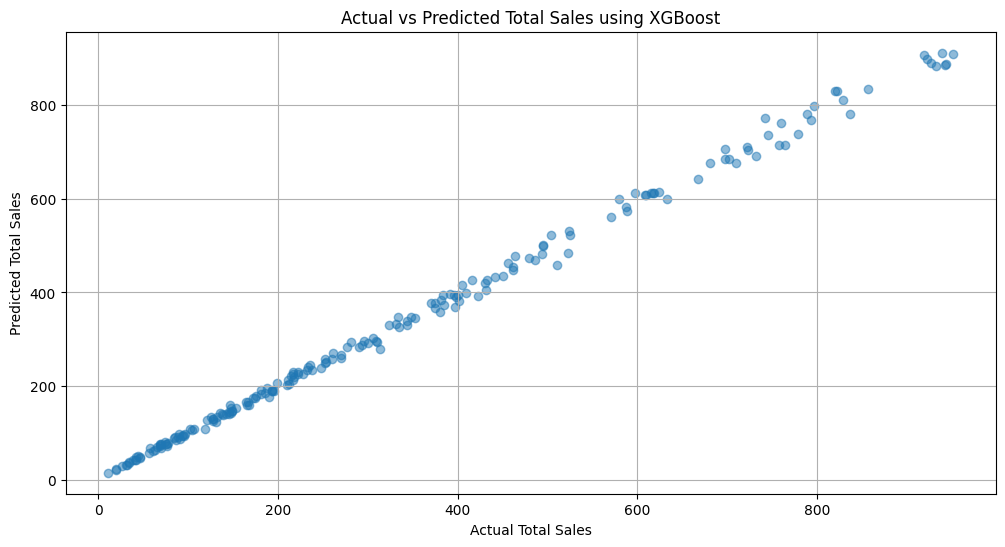

In [767]:
# Visualization
plt.figure(figsize=(12, 6))
plt.scatter(y_actual, y_pred, alpha=0.5)
plt.xlabel("Actual Total Sales")
plt.ylabel("Predicted Total Sales")
plt.title("Actual vs Predicted Total Sales using XGBoost")
plt.grid(True)
plt.show()

# 9. Model Evaluation  
   - Computes key performance metrics:  
     - **Mean Absolute Error (MAE)**  
     - **Root Mean Squared Error (RMSE)**  
     - **R² Score**  

In [769]:
# Model Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: 9.83
Mean Squared Error: 235.39
R2 Score: 0.9964


In [768]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring="r2")
print("Cross-Validation R² Scores:", scores)
print("Average R²:", scores.mean())

Cross-Validation R² Scores: [0.99606941 0.99650872 0.99620534 0.99660472 0.99655847]
Average R²: 0.9963893311568205


# 10. Feature Importance Plot  
   - Identifies the most significant features affecting sales predictions using **XGBoost’s feature importance plot**.


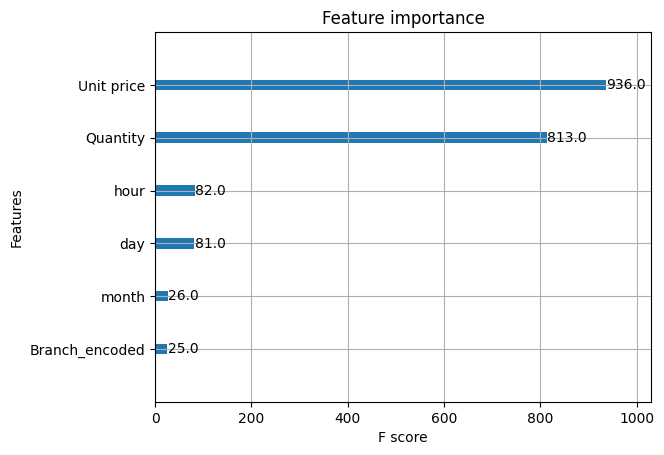

In [770]:
# Checking for important features
xgb.plot_importance(best_model)
plt.show()

# 11. Model Testing on Unseen Data  
   - Tests the trained model on unseen data.  
   - Ensures predictions are **log-transformed back to their original scale** for meaningful interpretation. 


### Steps:  
1. **Prepare Unseen Data**:  
   - We take a dataset that the model has never seen before.  
   - We ensure it contains the same features as the training set:  
     - `Unit price`, `Quantity`, `Branch_encoded`, `hour`, `day`, `month`, `year`.  

2. **Make Predictions**:  
   - We use the trained model to predict sales values for the unseen dataset.  
   - The predictions are stored in a new dataset called `y_pred`.  

3. **Compare with Actual Sales**:  
   - If actual sales data is available, we add it as a separate column (`Actual Sales`).  
   - This allows us to measure how close our predictions are to real values.  

In [805]:
# Unseen data
unseen_data = [
  {"Unit price": 45.20, "Quantity": 3, "Branch_encoded": 1, "hour": 14, "day": 12, "month": 3, "year": 2025},
  {"Unit price": 12.75, "Quantity": 5, "Branch_encoded": 2, "hour": 9, "day": 25, "month": 2, "year": 2025},
  {"Unit price": 78.50, "Quantity": 2, "Branch_encoded": 0, "hour": 16, "day": 7, "month": 1, "year": 2025},
  {"Unit price": 35.10, "Quantity": 4, "Branch_encoded": 1, "hour": 11, "day": 18, "month": 4, "year": 2025},
  {"Unit price": 89.99, "Quantity": 1, "Branch_encoded": 2, "hour": 13, "day": 30, "month": 5, "year": 2025},
  {"Unit price": 55.60, "Quantity": 6, "Branch_encoded": 0, "hour": 8, "day": 14, "month": 6, "year": 2025},
  {"Unit price": 22.45, "Quantity": 3, "Branch_encoded": 1, "hour": 17, "day": 21, "month": 7, "year": 2025},
  {"Unit price": 64.75, "Quantity": 7, "Branch_encoded": 2, "hour": 10, "day": 5, "month": 8, "year": 2025},
  {"Unit price": 41.30, "Quantity": 2, "Branch_encoded": 0, "hour": 12, "day": 19, "month": 9, "year": 2025},
  {"Unit price": 95.20, "Quantity": 5, "Branch_encoded": 1, "hour": 15, "day": 26, "month": 10, "year": 2025},
  {"Unit price": 48.99, "Quantity": 4, "Branch_encoded": 2, "hour": 9, "day": 8, "month": 11, "year": 2025},
  {"Unit price": 29.75, "Quantity": 6, "Branch_encoded": 0, "hour": 14, "day": 22, "month": 12, "year": 2025},
  {"Unit price": 82.50, "Quantity": 3, "Branch_encoded": 1, "hour": 18, "day": 11, "month": 1, "year": 2026},
  {"Unit price": 31.20, "Quantity": 2, "Branch_encoded": 2, "hour": 13, "day": 24, "month": 2, "year": 2026},
  {"Unit price": 74.40, "Quantity": 1, "Branch_encoded": 0, "hour": 10, "day": 6, "month": 3, "year": 2026},
  {"Unit price": 57.80, "Quantity": 5, "Branch_encoded": 1, "hour": 16, "day": 17, "month": 4, "year": 2026},
  {"Unit price": 39.99, "Quantity": 3, "Branch_encoded": 2, "hour": 11, "day": 29, "month": 5, "year": 2026},
  {"Unit price": 88.50, "Quantity": 6, "Branch_encoded": 0, "hour": 7, "day": 13, "month": 6, "year": 2026},
  {"Unit price": 26.70, "Quantity": 4, "Branch_encoded": 1, "hour": 15, "day": 20, "month": 7, "year": 2026},
  {"Unit price": 62.10, "Quantity": 7, "Branch_encoded": 2, "hour": 12, "day": 4, "month": 8, "year": 2026}
]

In [806]:
# Create DataFrame for unseen data
df_unseen = pd.DataFrame(unseen_data)

# Print the unseen data
print(df_unseen)

    Unit price  Quantity  Branch_encoded  hour  day  month  year
0        45.20         3               1    14   12      3  2025
1        12.75         5               2     9   25      2  2025
2        78.50         2               0    16    7      1  2025
3        35.10         4               1    11   18      4  2025
4        89.99         1               2    13   30      5  2025
5        55.60         6               0     8   14      6  2025
6        22.45         3               1    17   21      7  2025
7        64.75         7               2    10    5      8  2025
8        41.30         2               0    12   19      9  2025
9        95.20         5               1    15   26     10  2025
10       48.99         4               2     9    8     11  2025
11       29.75         6               0    14   22     12  2025
12       82.50         3               1    18   11      1  2026
13       31.20         2               2    13   24      2  2026
14       74.40         1 

*Since we applied a log transformation during training, we must apply an inverse transformation to interpret the predicted values correctly.*


In [799]:
y_pred_unseen = np.expm1(best_model.predict(df_unseen))

In [800]:
y_pred = pd.DataFrame(y_pred_unseen, columns=["predictions"])
y_pred

,predictions
0,151.125870
1,70.417725
2,176.014206
3,150.146210
4,96.477524
5,341.249603
6,70.610565
7,479.438782
8,90.647446
9,464.164337


In [801]:
df_actual_sales = [
  {"Actual Sales": 135.60},
  {"Actual Sales": 63.75},
  {"Actual Sales": 157.00},
  {"Actual Sales": 140.40},
  {"Actual Sales": 89.99},
  {"Actual Sales": 333.60},
  {"Actual Sales": 67.35},
  {"Actual Sales": 453.25},
  {"Actual Sales": 82.60},
  {"Actual Sales": 476.00},
  {"Actual Sales": 195.96},
  {"Actual Sales": 178.50},
  {"Actual Sales": 247.50},
  {"Actual Sales": 62.40},
  {"Actual Sales": 74.40},
  {"Actual Sales": 289.00},
  {"Actual Sales": 119.97},
  {"Actual Sales": 531.00},
  {"Actual Sales": 106.80},
  {"Actual Sales": 434.70}
]


# Create DataFrame for unseen data
df_actual_sales = pd.DataFrame(df_actual_sales)


In [802]:
df_actual_sales

,Actual Sales
0,135.60
1,63.75
2,157.00
3,140.40
4,89.99
5,333.60
6,67.35
7,453.25
8,82.60
9,476.00


*Calculate error metrics to measure model performance on unseen data.*

In [823]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute errors
mae = mean_absolute_error(df_actual_sales['Actual Sales'], y_pred['predictions'])
rmse = np.sqrt(mean_squared_error(df_actual_sales['Actual Sales'], y_pred['predictions']))
r2 = r2_score(df_actual_sales['Actual Sales'], y_pred['predictions'])

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 11.08
Root Mean Squared Error (RMSE): 13.13
R² Score: 0.9924


In [824]:
rmse = np.sqrt(mean_squared_error(df_actual_sales['Actual Sales'], y_pred['predictions']))
print(f"RMSE: {rmse}")

RMSE: 13.13261538311584


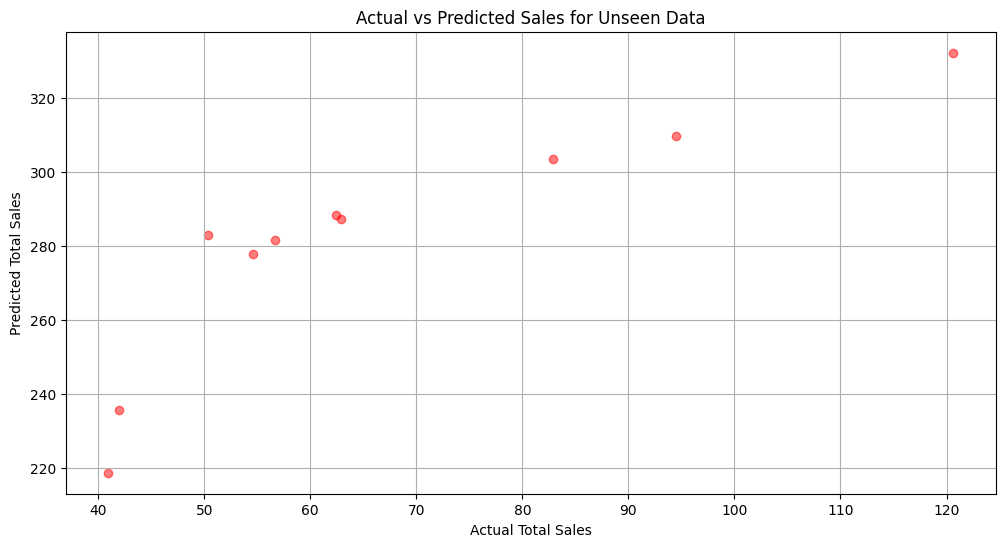

In [46]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.scatter(df_actual_sales['actual_sales'], y_pred['predictions'], alpha=0.5, color='red')
plt.xlabel("Actual Total Sales")
plt.ylabel("Predicted Total Sales")
plt.title("Actual vs Predicted Sales for Unseen Data")
plt.grid(True)
plt.show()